In [43]:
#supress tensorflow log printing
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

In [44]:
import pandas as pd
from IPython.display import display
import time
import numpy as np
import tools
import misc_tools
from matplotlib import pyplot as plt
import tensorflow as tf
import scipy.stats
%load_ext autoreload
%autoreload 2
sims = "sims"
models_file = "../models/trained_chiTest4/"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [45]:
#loading data
data = tools.create_simulated_data.txt_file_split_to_npy("../data/simCatalog_three_pix_triout_chiTest4.txt", seed = 31)
x_train, y_train, x_val, y_val, x_test, y_test = data[sims]

## Models <a class="anchor" id="Models"></a>
All neural networks that were trained have 2 inputs:
- x(shape: # of examples, 5): Values of measured r, ug, gr, ri and iz magnitudes
- xerror(shape: # of examples, 5): Values of corresponding errors

All neural networks are probbabilistic models that predict 2 outputs for each value of y:
- p(shape: # of examples, 2): Predicted values for Mr, Ar and Fe/H
- sigma_p(shape: # of examples, 2): Predicted values for standard deviation of Mr, Ar and Fe/H

Error function that is minimized is taken from the moment network paper:
\begin{align}
    error = \sum \left[ (y-p)^2 + \left( (y-p)^2 - \sigma_p^2 \right) ^2 \right]
\end{align}
where p is the predicted value for Mr, Ar or Fe/H, while y is the true value.

There are number of models tested that predict values for Mr, Ar and Fe/H in a different ways. They can be categorized in two major categories of models:
- single output models
- multi output models

**Single output** models use some or all inputs to predict only one value; either Mr, Ar or Fe/H. This means they are tuned and trained to predict only one value. This means that for predicting Mr, Ar and Fe/H we need 3 seprately trained neural networks for the same input. This trio of separatley trained and tuned networks are then merged into one neural network that predict all outputs at the same time from the inputs.

**Multi output** models use the inputs to predict all the outputs at the same time. This type of network is trained to predict all the inputs at the same time. Loss function for each value of Mr, Ar and Fe/H is weighted using following expression:
\begin{align}
    MD^2 = \frac{error_{Mr}}{0.1^2} + \frac{error_{Ar}}{0.02^2} + \frac{error_{Fe/H}}{0.1^2}
\end{align}
 where $error_{Mr}$, $error_{Ar}$ and $error_{Fe/H}$ are corresponding values of the error that network is trying to minimize. Values of 0.1 mag, 0.02 mag i 0.1 dex are tipical minimal values using similar methods with fotometric accuracy of around 0.01-0.02 mag.

For every major category there are three minor subcategories:
- simple model
- probabilistic model

**Simple model** is the model that discards the xerror input and uses only information about x. This model does not understand that inputs represent normal distributions with $\mu_x=x$ and $\sigma_x = xerrors$. This model assumes mesurments are always perfect at x. Output of this model are numbers, but it could be modified to use this model to predict normal distributions. This could be done by sampling inputs from N(x,xerror), then predicting outputs on the sampled inputs, and then calculating $\mu_y$ and $\sigma_y$. Doing this some amount of accuracy (in this case correlation) will be lost, but information about standard deviation on the output will be gained.

**Probabilistic model** uses the information about both x and xerror. However, it is not treating the inputs as N(x,xerror), only as 2 sets of numbers. This naive approach could utilize information about xerror, but since its outputs are vectors, not distribution it can't predict standard deviation of the output.

### Single output models <a class="anchor" id="SOM"></a>
#### Simple single output model <a class="anchor" id="SSOM"></a>

RAM usage in GB: 0.34199833
Parameter numbers: 20568
Zero parameters: 0.0


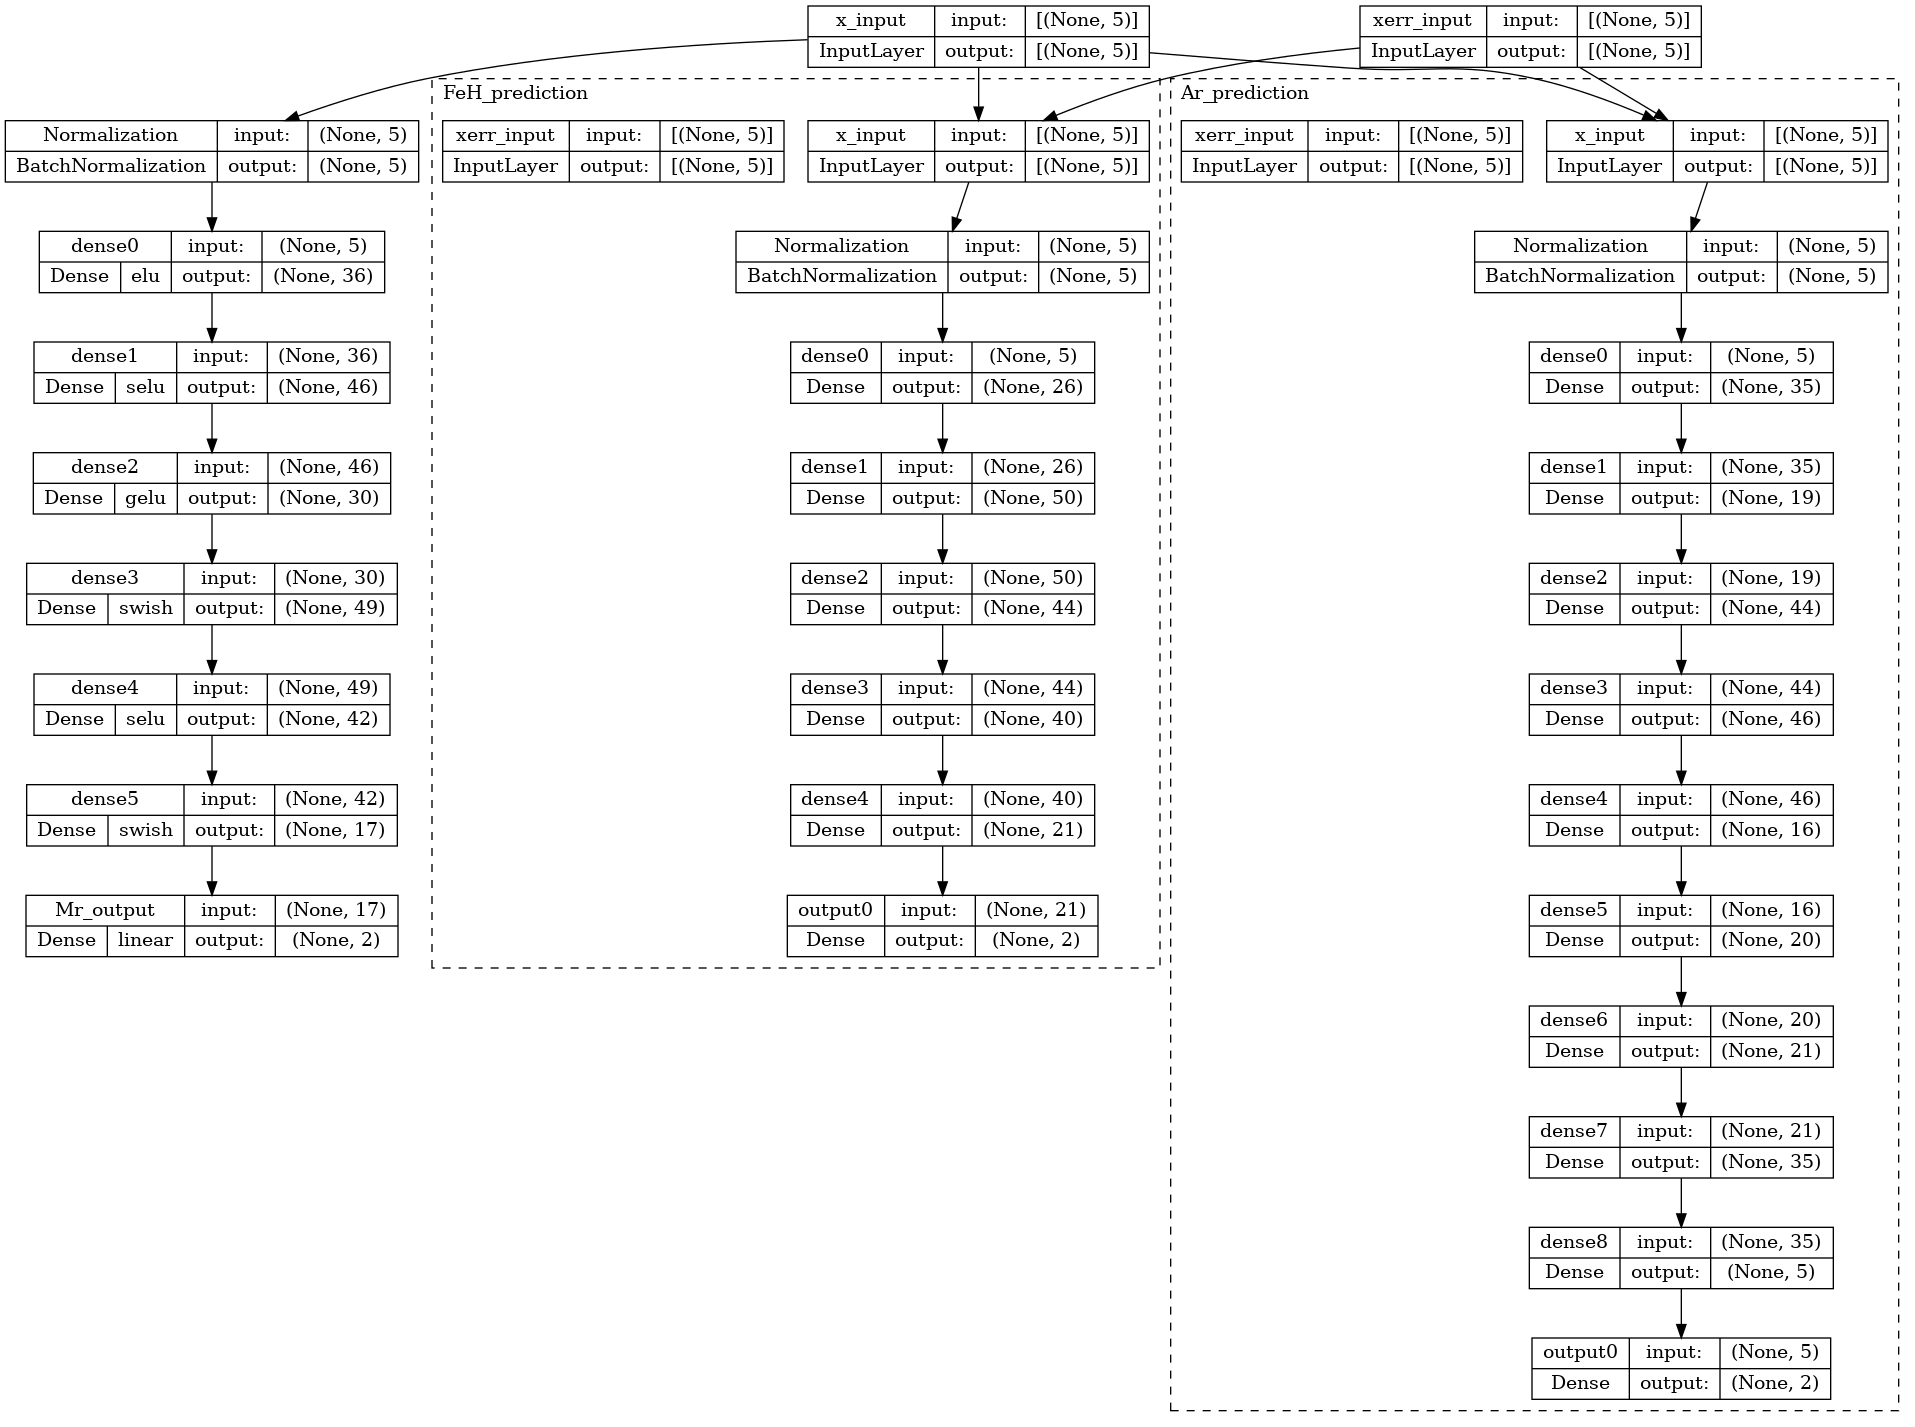

In [46]:
model = tf.keras.models.load_model(models_file + "photozannv14p_trained", compile=False)
os.makedirs("./IMAGES/SimpleSingle/", exist_ok=True)
img_path = "./IMAGES/SimpleSingle/"
model_usage = tools.create_model.model_memory_usage(model, batch_size=x_test[0].shape[0])
param_nums, zero_params = tools.create_model.model_parameter_num(model)
print("RAM usage in GB:", model_usage / 1e9)
print("Parameter numbers:", param_nums)
print("Zero parameters:", zero_params)

tf.keras.utils.plot_model(model, to_file=img_path+"model.png", show_shapes=True, show_layer_activations=True, show_layer_names=True, expand_nested=True)

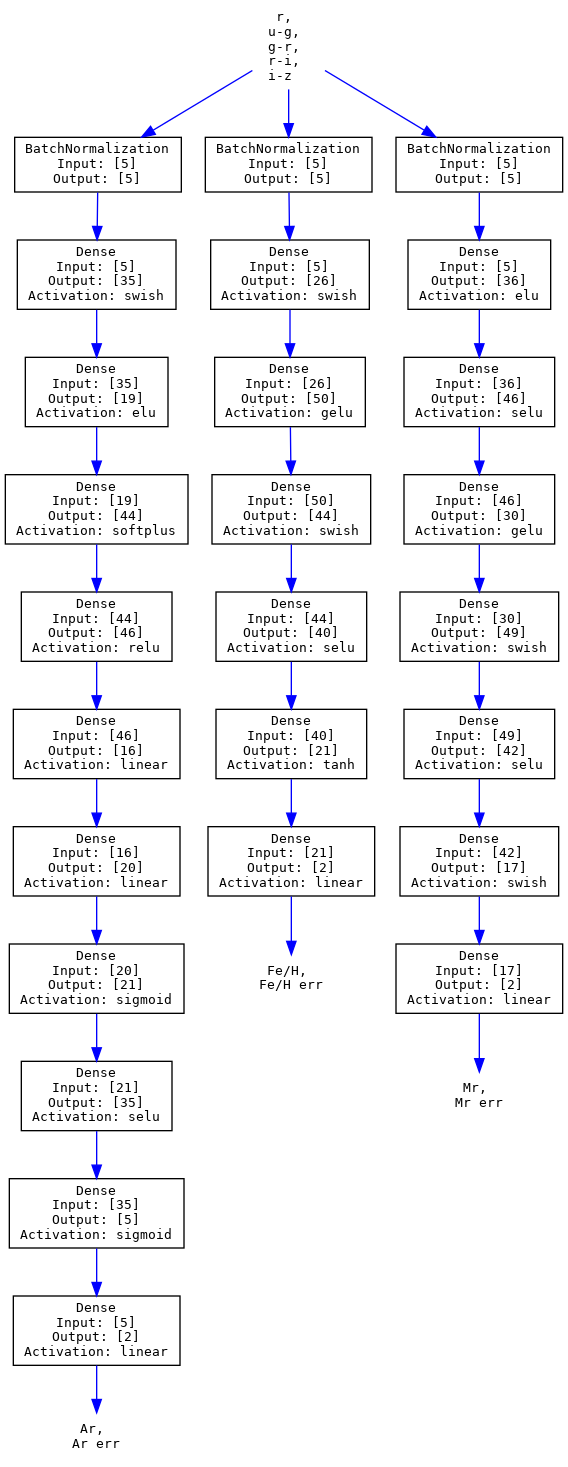

In [47]:
pydot_graph = misc_tools.plotModel (model, ["r, \nu-g, \ng-r, \nr-i, \ni-z  "], ["Ar, \nAr err", "Fe/H, \nFe/H err", "Mr, \nMr err"])
misc_tools.view_pydot(pydot_graph)
pydot_graph.write_png(img_path+"model.png")

In [23]:
start_time = time.time()
prediction = model (x_test)
sigma_p = ([np.abs(np.array(prediction[i])).reshape((-1,2))[:, -1:] for i in range (len(prediction))]) #cleaning shapes of the sigma outputs
p = tuple ([np.array(prediction[i]).reshape((-1,2))[:, :1] for i in range (len(prediction))]) #cleaning shapes of the outputs
print ("Time taken for "+str(p[0].shape[0])+" predictions :", time.time()-start_time, "seconds")
print ("Mean corelation of this model is:", np.array([np.corrcoef (y_test[i][:,0], p[i][:, 0]) [0,1] for i in range(len(p))]).mean())

Time taken for 122656 predictions : 1.0151426792144775 seconds
Mean corelation of this model is: 0.9196257745786895


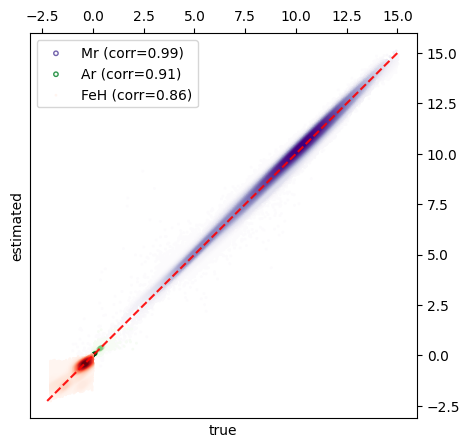

In [24]:
fig, ax = plt.subplots(figsize=(5,5))
fig.set_facecolor('white')
name=["Mr", "Ar", "FeH"]
for i in range (len(name)):
    name[i] = name[i]+" (corr="+str(round (np.corrcoef (y_test[i][:,0], p[i][:, 0]) [0,1], 2))+")"
tools.eval_tools.plot_correlation(y_test, p, ax, name=name, small_size =200)
plt.savefig(img_path+"All_correlation.png", bbox_inches='tight')
plt.show()

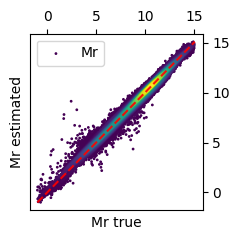

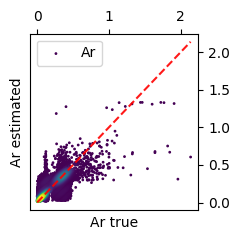

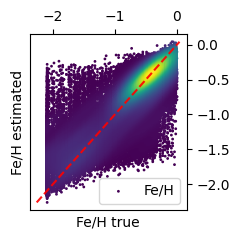

In [25]:
names=["Mr", "Ar", "Fe/H"]
#fig, ax = plt.subplots(len(names), figsize=(5,len(names)*5))
#fig.set_facecolor('white')
for i in range (len(names)):
    fig, ax = plt.subplots(1, figsize=(2.5,2.5))
    fig.set_facecolor('white')
    name = names[i]
    ax=tools.eval_tools.plot_correlation(y_test[i], p[i], ax, name=name, small_size=200)
    fig.tight_layout()
    
    fig.savefig(img_path+name.replace("/","")+"_correlation.png", bbox_inches='tight')
plt.show()

$\mu$($Ar_{e} - Ar_{t}$)=-0.0
$\sigma$($Ar_{e} - Ar_{t}$)=0.02
$\mu$($Mr_{e} - Mr_{t}$)=0.04
$\sigma$($Mr_{e} - Mr_{t}$)=0.25
$\mu$($Fe/H_{e} - Fe/H_{t}$)=-0.02
$\sigma$($Fe/H_{e} - Fe/H_{t}$)=0.16


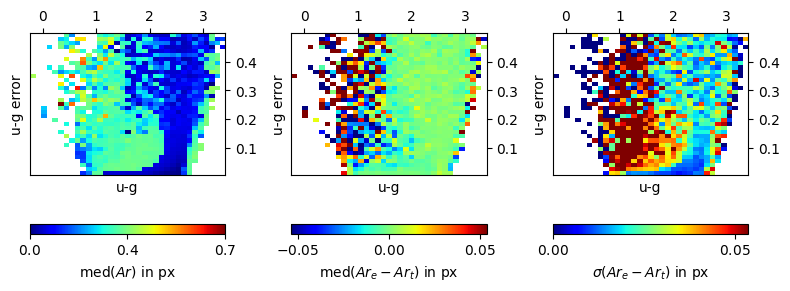

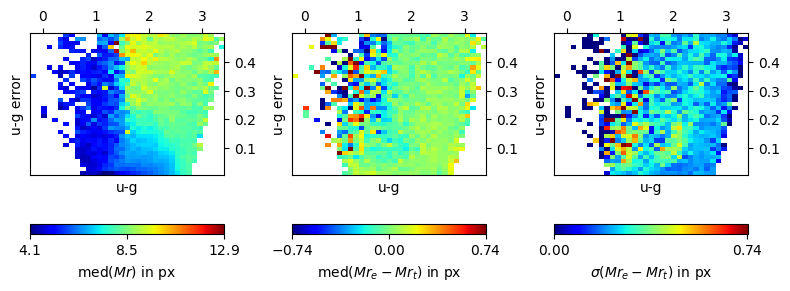

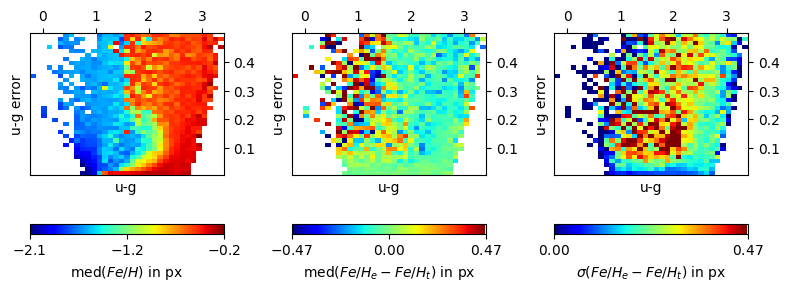

In [26]:
Mrsample_true, Arsample_true, FeHsample_true = (y_test[i][:,0] for i in range (len(y_test)))

r_magSample, ugSample, grSample, riSample, izSample = (x_test[0][:,i] for i in range (x_test[0].shape[1]))
r_magErrSample, ugErrSample, grErrSample, riErrSample, izErrSample = (x_test[1][:,i] for i in range (x_test[1].shape[1]))
Mrsample, Arsample, FeHsample = tuple ([np.array(p[i]).reshape((-1)) for i in range (len(p))]) #cleaning shapes of the outputs
figar = misc_tools.pike_plot_multiple(Arsample[ugErrSample<0.5], ugSample[ugErrSample<0.5], ugErrSample[ugErrSample<0.5],
                           Arsample_true[ugErrSample<0.5], value_name="Ar")
figar.savefig(img_path+"Ar_pike.png", bbox_inches='tight')
figmr = misc_tools.pike_plot_multiple(Mrsample[ugErrSample<0.5], ugSample[ugErrSample<0.5], ugErrSample[ugErrSample<0.5],
                           Mrsample_true[ugErrSample<0.5], value_name="Mr")
figmr.savefig(img_path+"Mr_pike.png", bbox_inches='tight')
figfeh = misc_tools.pike_plot_multiple(FeHsample[ugErrSample<0.5], ugSample[ugErrSample<0.5], ugErrSample[ugErrSample<0.5],
                           FeHsample_true[ugErrSample<0.5], value_name="Fe/H")
figfeh.savefig(img_path+"FeH_pike.png", bbox_inches='tight')

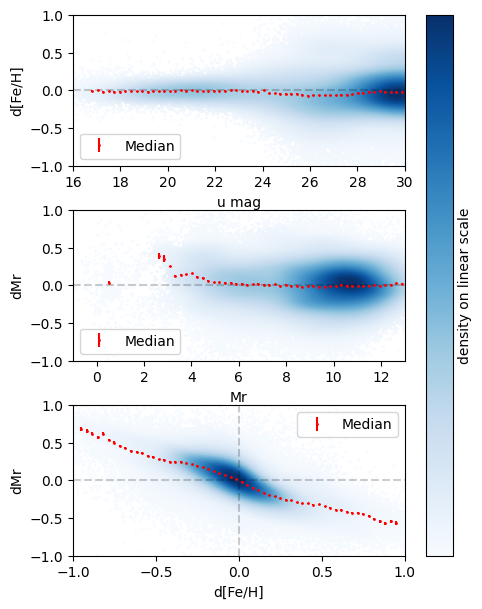

In [27]:
_ = misc_tools.plot_2D_multiple (x_test, p, y_test)
plt.savefig(img_path+"bias.png", bbox_inches='tight')

Histograms of estimated sigma


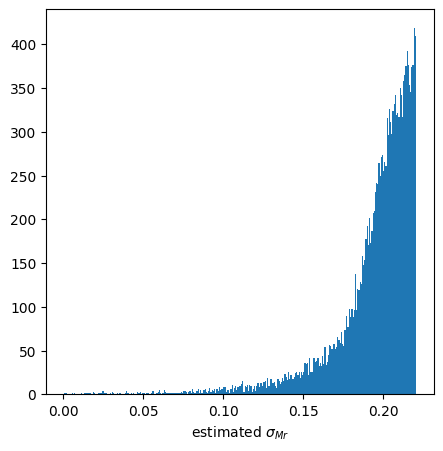

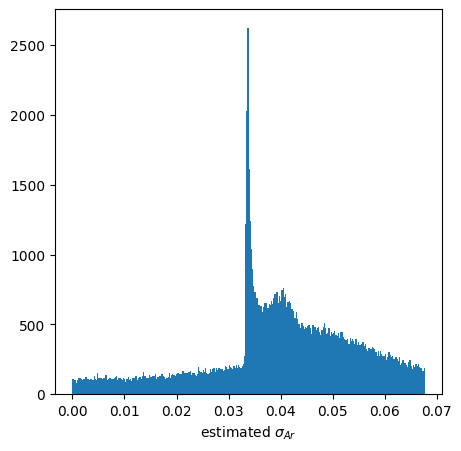

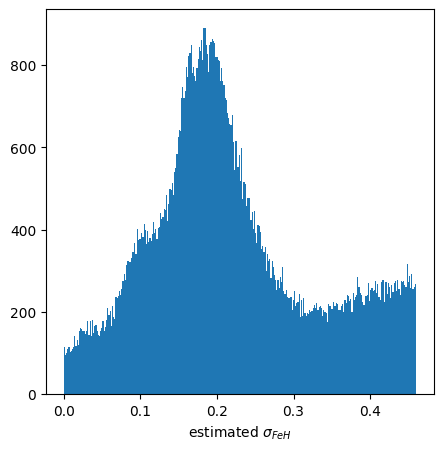

In [28]:
print ("Histograms of estimated sigma")
#fig, ax = plt.subplots(1, 3, figsize=(3*5,5))
outputs = ["Mr", "Ar", "FeH"]
for i, name in enumerate(outputs):
    fig, ax = plt.subplots(1, figsize=(5,5))
    ax = misc_tools.plot_sigma_histogram (ax, sigma_p[i], (sigma_p[i].min(), sigma_p[i].min()+3*tools.eval_tools.sigGzi(sigma_p[i])), name)

Histograms of expected N(0,1)


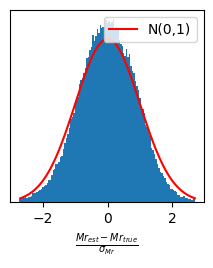

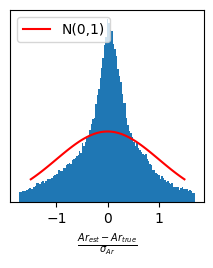

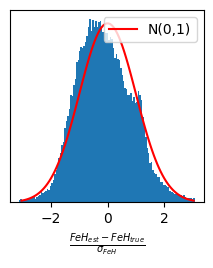

In [29]:
print ("Histograms of expected N(0,1)")
ax_1=[]
fig_1=[]
for i in range (3):
    fig, ax = plt.subplots(1, figsize=(2.5,2.5))
    ax_1.append(ax)
    fig_1.append(fig)
fig = misc_tools.plot_expected_gauss(p, sigma_p, y_test, outputs, ax_1, nbins=120)
names=["Mr", "Ar", "Fe/H"]
for i,fig in enumerate(fig_1):
    fig.savefig(img_path+names[i].replace("/","") +"_gauss.png", bbox_inches='tight')

In [30]:
mse = tf.keras.losses.MeanSquaredError()(y_test, p).numpy()

differences_sigma = [np.abs(y_test[i] - p[i])<sigma_p[i] for i in range (len (p))]
inside_sigma = [differences_sigma[i].sum() for i in range (len (p))]
inside_sigma.append(np.array (differences_sigma).all (axis=0).sum())
inside_sigma = np.array(inside_sigma) / p[0].shape[0]

differences_sigma_mse = [np.abs(y_test[i] - p[i])<sigma_p[i]+mse for i in range (len (p))]
inside_sigma_mse = [differences_sigma_mse[i].sum() for i in range (len (p))]
inside_sigma_mse.append(np.array (differences_sigma_mse).all (axis=0).sum())
inside_sigma_mse = np.array(inside_sigma_mse) / p[0].shape[0]

table = pd.DataFrame([inside_sigma, inside_sigma_mse], columns=["Mr (expect 0.68)", "Ar (expect 0.68)", "Fe/H (expect 0.68)", "All (expect 0.32)"],
                          index=["Percent inside est sigma", "Percent inside (est sigma + MSE)"])
print ("Table of coverage:")
display(table)

Table of coverage:


,Mr (expect 0.68),Ar (expect 0.68),Fe/H (expect 0.68),All (expect 0.32)
Percent inside est sigma,0.732365,0.794262,0.662308,0.471392
Percent inside (est sigma + MSE),0.821542,0.952754,0.802831,0.697406


/mnt/Storage/Projects/BEAST_LSST/Results/misc_tools.py:131: RuntimeWarning: invalid value encountered in scalar divide
  y_test[i][(y_test[i] >= bins[j]) & (y_test[i] <= bins[j + 1])].shape[0] for j in


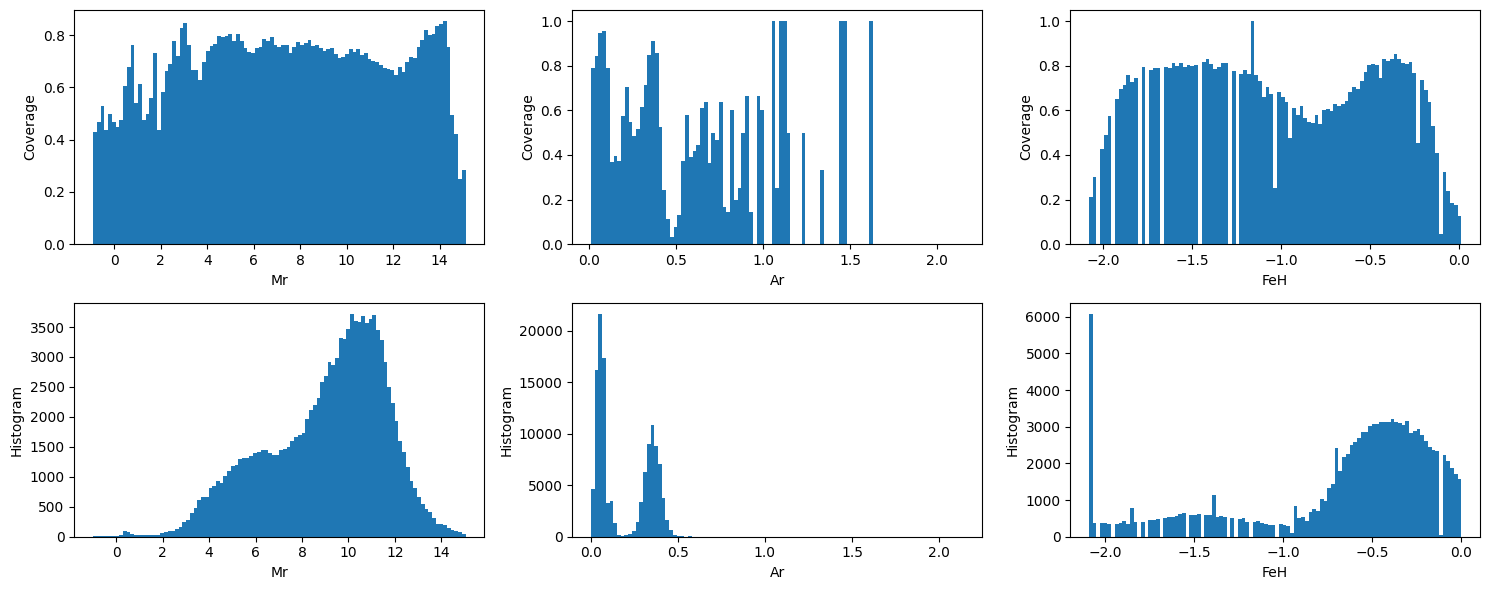

In [31]:
_ = misc_tools.plot_sigma_dependency(p, sigma_p, y_test)

#### Probbabilistic single output model <a class="anchor" id="NSOM"></a>

RAM usage in GB: 0.486753622
Parameter numbers: 30956
Zero parameters: 0.0


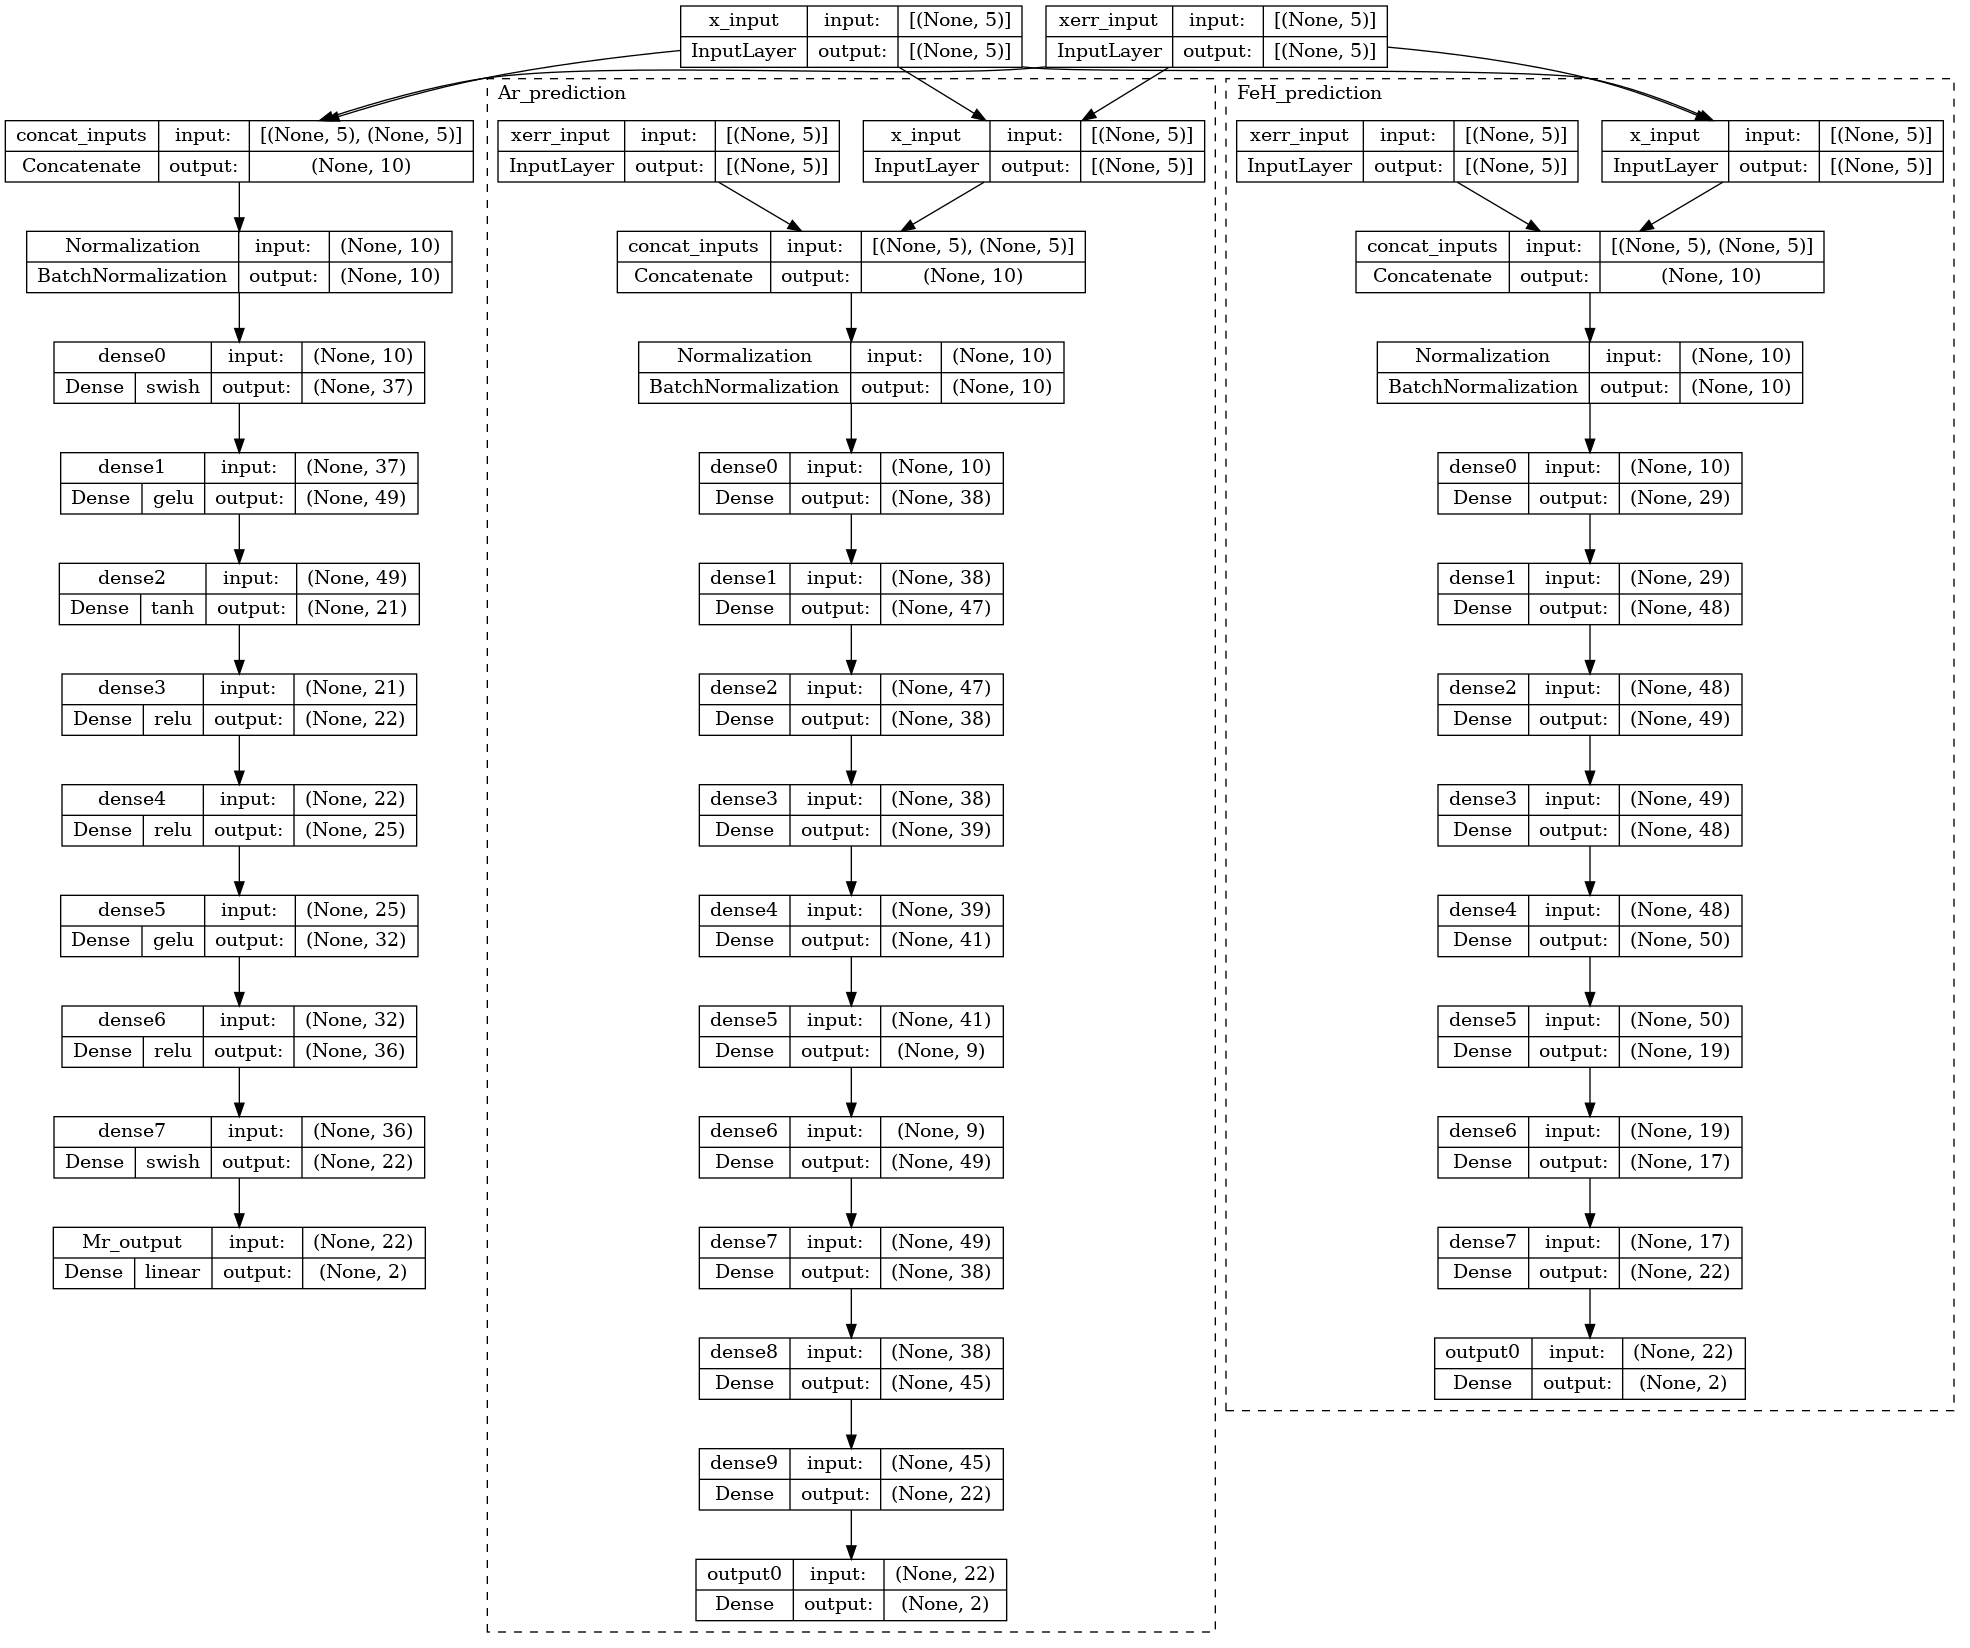

In [32]:
model = tf.keras.models.load_model(models_file + "photozannv24p_trained", compile=False)
os.makedirs("./IMAGES/ProbabilisticSingle/", exist_ok=True)
img_path = "./IMAGES/ProbabilisticSingle/"
model_usage = tools.create_model.model_memory_usage(model, batch_size=x_test[0].shape[0])
param_nums, zero_params = tools.create_model.model_parameter_num(model)
print("RAM usage in GB:", model_usage / 1e9)
print("Parameter numbers:", param_nums)
print("Zero parameters:", zero_params)

tf.keras.utils.plot_model(model, to_file=img_path+"model.png" ,show_shapes=True, show_layer_activations=True, show_layer_names=True, expand_nested=True)

['Ar_prediction_output0', 'FeH_prediction_output0', 'Mr_output']


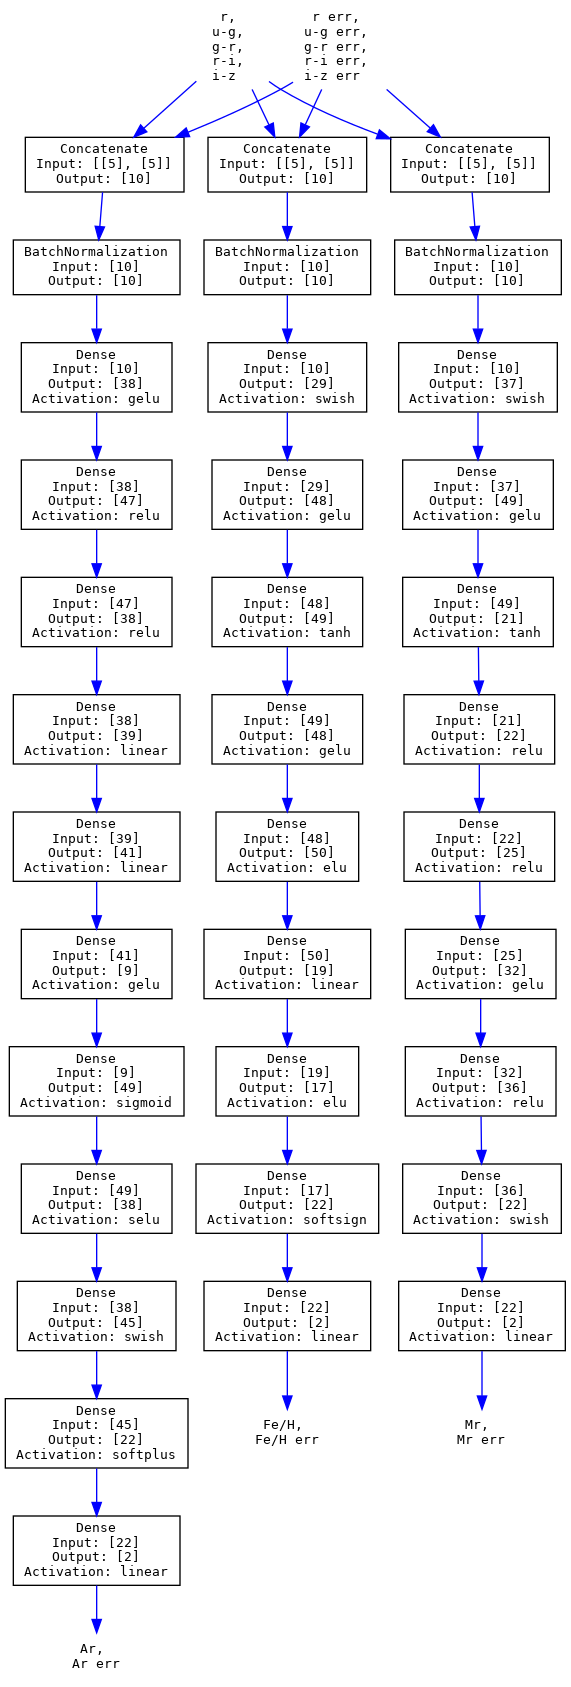

In [33]:
pydot_graph = misc_tools.plotModel (model, ["r, \nu-g, \ng-r, \nr-i, \ni-z  ", "r err, \nu-g err, \ng-r err, \nr-i err, \ni-z err  "], ["Ar, \nAr err", "Fe/H, \nFe/H err", "Mr, \nMr err"])
misc_tools.view_pydot(pydot_graph)
pydot_graph.write_png(img_path+"model.png")

In [34]:
start_time = time.time()
prediction = model (x_test)
sigma_p = ([np.abs(np.array(prediction[i])).reshape((-1,2))[:, -1:] for i in range (len(prediction))]) #cleaning shapes of the sigma outputs
p = tuple ([np.array(prediction[i]).reshape((-1,2))[:, :1] for i in range (len(prediction))]) #cleaning shapes of the outputs
print ("Time taken for "+str(p[0].shape[0])+" predictions :", time.time()-start_time, "seconds")
print ("Mean corelation of this model is:", np.array([np.corrcoef (y_test[i][:,0], p[i][:, 0]) [0,1] for i in range(len(p))]).mean())

Time taken for 122656 predictions : 0.5405335426330566 seconds
Mean corelation of this model is: 0.9193745632671199


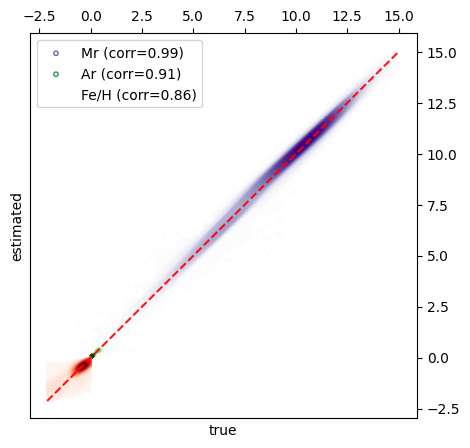

In [35]:
fig, ax = plt.subplots(figsize=(5,5))
fig.set_facecolor('white')
name=["Mr", "Ar", "Fe/H"]
for i in range (len(name)):
    name[i] = name[i]+" (corr="+str(round (np.corrcoef (y_test[i][:,0], p[i][:, 0]) [0,1], 2))+")"
tools.eval_tools.plot_correlation(y_test, p, ax, name=name, small_size =200)
plt.savefig(img_path+"All_correlation.png", bbox_inches='tight')
plt.show()

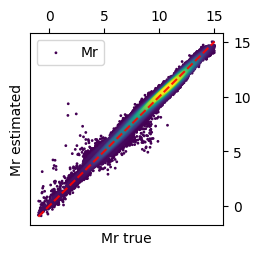

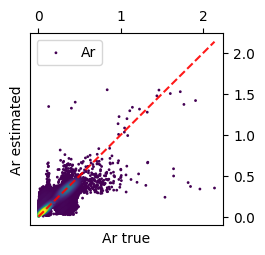

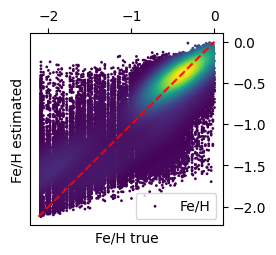

In [36]:
names=["Mr", "Ar", "Fe/H"]
for i in range (len(names)):
    fig, ax = plt.subplots(1, figsize=(2.5,2.5))
    fig.set_facecolor('white')
    name = names[i]
    ax=tools.eval_tools.plot_correlation(y_test[i], p[i], ax, name=name, small_size=200)
    fig.savefig(img_path+name.replace("/","")+"_correlation.png", bbox_inches='tight')
    plt.show()

$\mu$($Ar_{e} - Ar_{t}$)=0.0
$\sigma$($Ar_{e} - Ar_{t}$)=0.02
$\mu$($Mr_{e} - Mr_{t}$)=0.04
$\sigma$($Mr_{e} - Mr_{t}$)=0.25
$\mu$($\frac{Fe}{H}_{e} - \frac{Fe}{H}_{t}$)=-0.01
$\sigma$($\frac{Fe}{H}_{e} - \frac{Fe}{H}_{t}$)=0.16


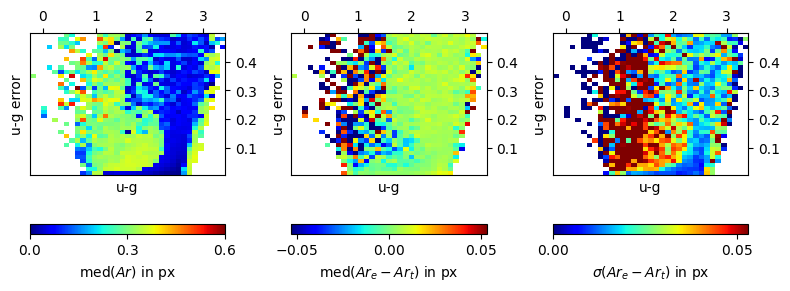

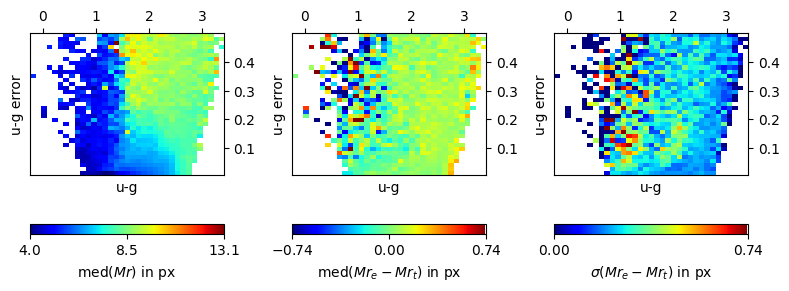

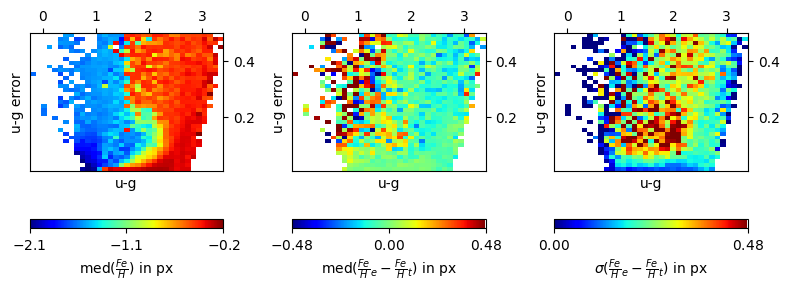

In [37]:
Mrsample_true, Arsample_true, FeHsample_true = (y_test[i][:,0] for i in range (len(y_test)))

r_magSample, ugSample, grSample, riSample, izSample = (x_test[0][:,i] for i in range (x_test[0].shape[1]))
r_magErrSample, ugErrSample, grErrSample, riErrSample, izErrSample = (x_test[1][:,i] for i in range (x_test[1].shape[1]))
Mrsample, Arsample, FeHsample = tuple ([np.array(p[i]).reshape((-1)) for i in range (len(p))]) #cleaning shapes of the outputs
figar = misc_tools.pike_plot_multiple(Arsample[ugErrSample<0.5], ugSample[ugErrSample<0.5], ugErrSample[ugErrSample<0.5],
                           Arsample_true[ugErrSample<0.5], value_name="Ar")
figar.savefig(img_path+"Ar_pike.png", bbox_inches='tight')
figmr = misc_tools.pike_plot_multiple(Mrsample[ugErrSample<0.5], ugSample[ugErrSample<0.5], ugErrSample[ugErrSample<0.5],
                           Mrsample_true[ugErrSample<0.5], value_name="Mr")
figmr.savefig(img_path+"Mr_pike.png", bbox_inches='tight')
figfeh = misc_tools.pike_plot_multiple(FeHsample[ugErrSample<0.5], ugSample[ugErrSample<0.5], ugErrSample[ugErrSample<0.5],
                           FeHsample_true[ugErrSample<0.5], value_name=r"\frac{Fe}{H}")
figfeh.savefig(img_path+"FeH_pike.png", bbox_inches='tight')

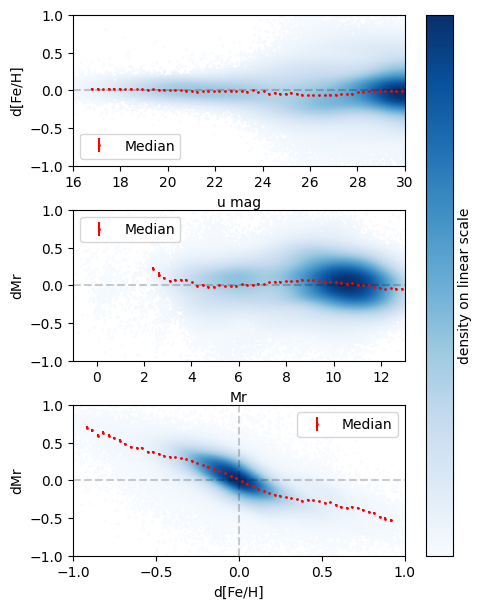

In [38]:
_ = misc_tools.plot_2D_multiple (x_test, p, y_test)
plt.savefig(img_path+"bias.png", bbox_inches='tight')

Histograms of estimated sigma


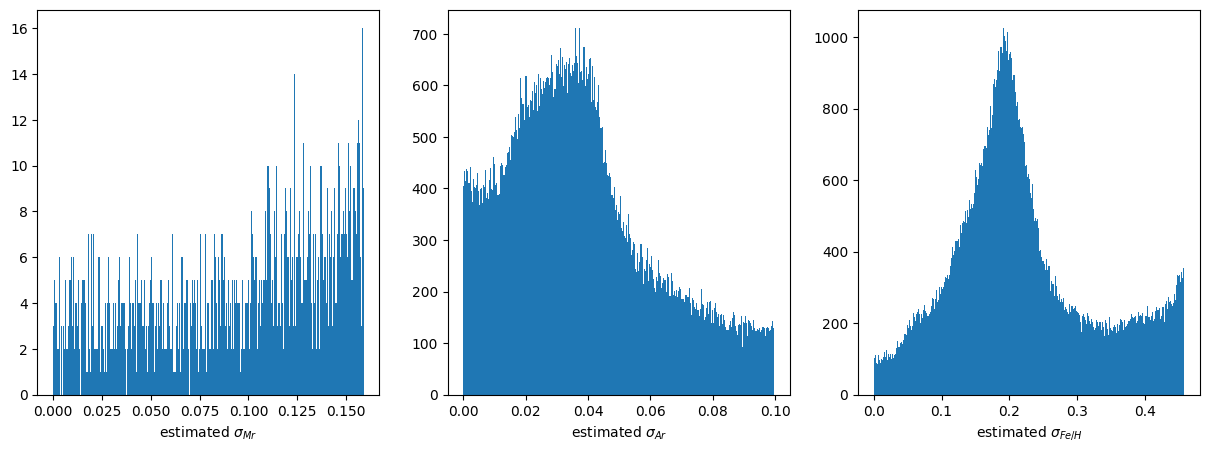

In [39]:
print ("Histograms of estimated sigma")
fig, ax = plt.subplots(1, 3, figsize=(3*5,5))
outputs = ["Mr", "Ar", "Fe/H"]
for i, name in enumerate(outputs):
    ax[i] = misc_tools.plot_sigma_histogram (ax[i], sigma_p[i], (sigma_p[i].min(), sigma_p[i].min()+3*tools.eval_tools.sigGzi(sigma_p[i])), name)

Histograms of expected N(0,1)


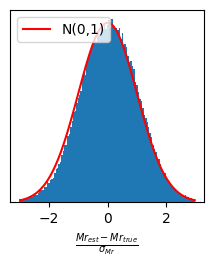

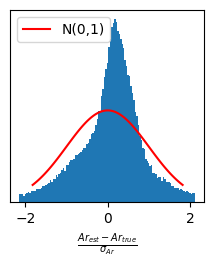

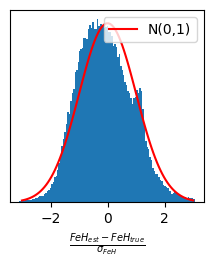

In [40]:
print ("Histograms of expected N(0,1)")
ax_1=[]
fig_1=[]
for i in range (3):
    fig, ax = plt.subplots(1, figsize=(2.5,2.5))
    ax_1.append(ax)
    fig_1.append(fig)
fig = misc_tools.plot_expected_gauss(p, sigma_p, y_test, outputs, ax_1, nbins=120)
names=["Mr", "Ar", "Fe/H"]
for i,fig in enumerate(fig_1):
    fig.savefig(img_path+names[i].replace("/","")+"_gauss.png", bbox_inches='tight')

In [41]:
mse = tf.keras.losses.MeanSquaredError()(y_test, p).numpy()

differences_sigma = [np.abs(y_test[i] - p[i])<sigma_p[i] for i in range (len (p))]
inside_sigma = [differences_sigma[i].sum() for i in range (len (p))]
inside_sigma.append(np.array (differences_sigma).all (axis=0).sum())
inside_sigma = np.array(inside_sigma) / p[0].shape[0]

differences_sigma_mse = [np.abs(y_test[i] - p[i])<sigma_p[i]+mse for i in range (len (p))]
inside_sigma_mse = [differences_sigma_mse[i].sum() for i in range (len (p))]
inside_sigma_mse.append(np.array (differences_sigma_mse).all (axis=0).sum())
inside_sigma_mse = np.array(inside_sigma_mse) / p[0].shape[0]

table = pd.DataFrame([inside_sigma, inside_sigma_mse], columns=["Mr (expect 0.68)", "Ar (expect 0.68)", "Fe/H (expect 0.68)", "All (expect 0.32)"],
                          index=["Percent inside est sigma", "Percent inside (est sigma + MSE)"])
print ("Table of coverage:")
display(table)

Table of coverage:


,Mr (expect 0.68),Ar (expect 0.68),Fe/H (expect 0.68),All (expect 0.32)
Percent inside est sigma,0.682404,0.734012,0.668993,0.418716
Percent inside (est sigma + MSE),0.781976,0.952126,0.806483,0.674504


/mnt/Storage/Projects/BEAST_LSST/Results/misc_tools.py:131: RuntimeWarning: invalid value encountered in scalar divide
  y_test[i][(y_test[i] >= bins[j]) & (y_test[i] <= bins[j + 1])].shape[0] for j in


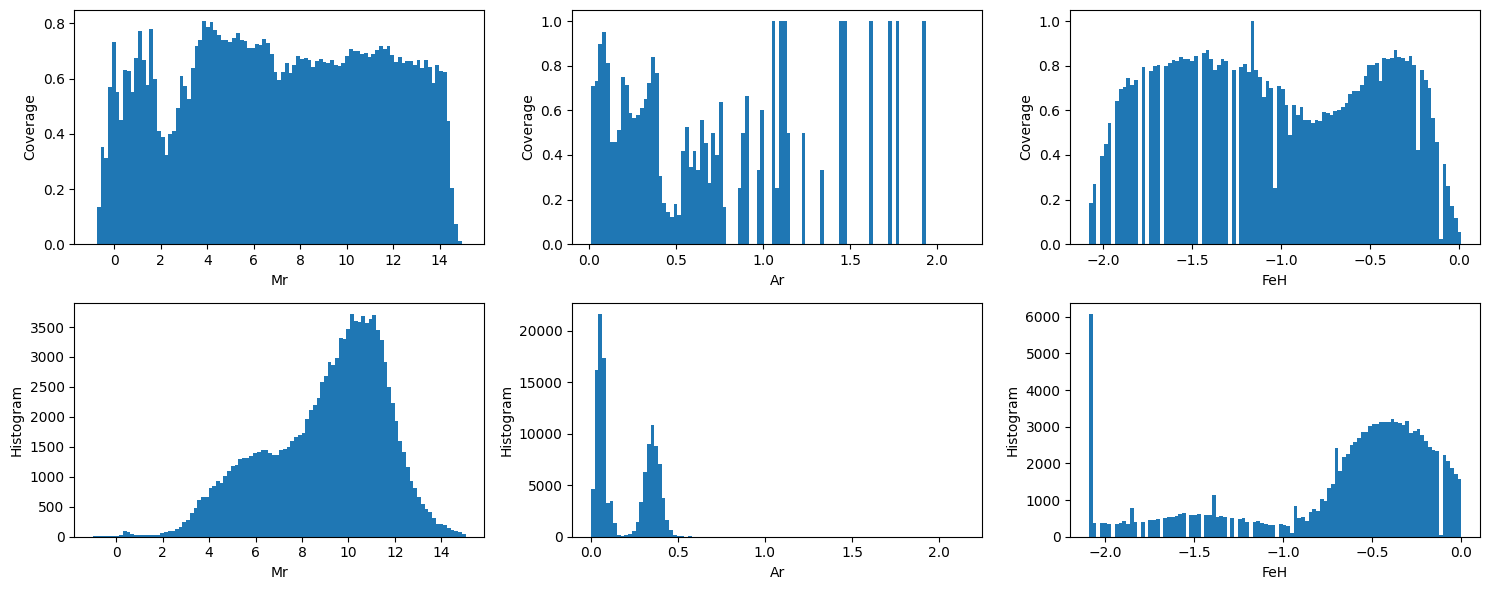

In [42]:
_ = misc_tools.plot_sigma_dependency(p, sigma_p, y_test)